# K-means on the Wisconsin Diagnostic Breast Cancer dataset
An exploratory clustering example using the dataset bundled with scikit-learn (569 observations,
30 measurements). Scaling and clustering use all observations without diagnosis labels.
Labels are consulted afterward for descriptive agreement only. There is no independent test set,
so these values do not estimate diagnostic or future-patient performance.

In [1]:
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/kmeans_scratch.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from within its repository folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
from src.kmeans_scratch import kmeans

data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
y = data.target
print(f'{X.shape[0]} observations; {X.shape[1]} standardized features')
centers, scratch_labels = kmeans(X, k=2, random_state=42)
reference = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
reference_labels = reference.labels_
rows = []
for name, labels, centroids in [('NumPy: one random start', scratch_labels, centers),
                                ('scikit-learn: 20 k-means++ starts', reference_labels, reference.cluster_centers_)]:
    rows.append({'implementation': name,
                 'inertia': ((X-centroids[labels])**2).sum(),
                 'silhouette': silhouette_score(X, labels),
                 'adjusted_rand_with_diagnosis': adjusted_rand_score(y, labels)})
display(pd.DataFrame(rows))

569 observations; 30 standardized features


,implementation,inertia,silhouette,adjusted_rand_with_diagnosis
0,NumPy: one random start,11595.526607,0.343382,0.653625
1,scikit-learn: 20 k-means++ starts,11595.461474,0.344974,0.670721


This comparison uses different initialization budgets deliberately: the scratch function illustrates
one Lloyd iteration loop; the reference runs 20 initializations. Differences are not evidence that
one implementation is intrinsically better. Cluster numbers have no inherent diagnostic meaning.

In-sample label agreement after mapping: 0.910
Rows: recorded diagnosis; columns: mapped cluster (malignant, benign)
[[175  37]
 [ 14 343]]


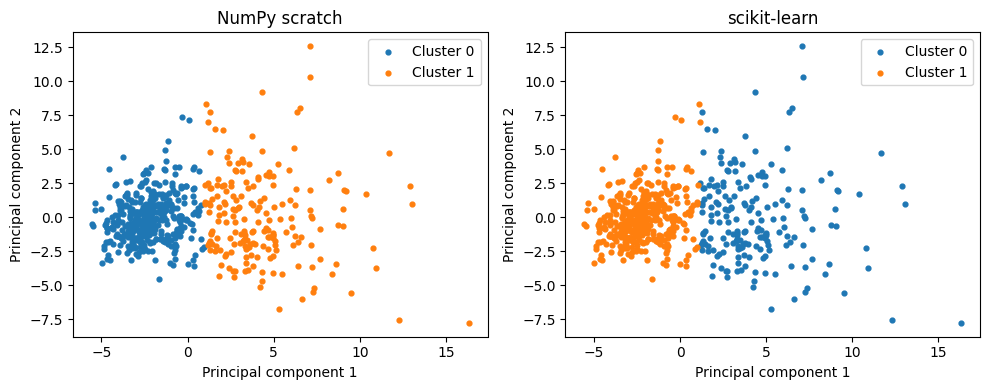

In [3]:
# Map the two reference clusters for description of these same observations only.
direct = (reference_labels == y).mean()
flipped = (1-reference_labels == y).mean()
mapped = reference_labels if direct >= flipped else 1-reference_labels
print(f'In-sample label agreement after mapping: {(mapped == y).mean():.3f}')
print('Rows: recorded diagnosis; columns: mapped cluster (malignant, benign)')
print(confusion_matrix(y, mapped, labels=[0, 1]))

projection = PCA(n_components=2).fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, labels, title in zip(axes, [scratch_labels, reference_labels], ['NumPy scratch', 'scikit-learn']):
    for cluster in np.unique(labels):
        selected = labels == cluster
        ax.scatter(projection[selected, 0], projection[selected, 1], s=12, label=f'Cluster {cluster}')
    ax.set(xlabel='Principal component 1', ylabel='Principal component 2', title=title)
    ax.legend()
plt.tight_layout(); plt.show()

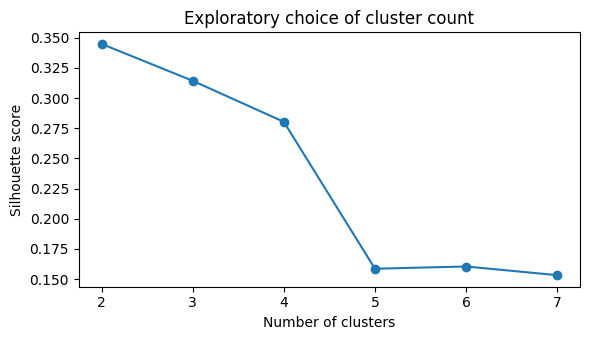

In [4]:
# Descriptive sensitivity to k, using the same feature observations throughout.
ks = list(range(2, 8))
scores = [silhouette_score(X, KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X)) for k in ks]
plt.figure(figsize=(6, 3.5))
plt.plot(ks, scores, marker='o')
plt.xlabel('Number of clusters'); plt.ylabel('Silhouette score')
plt.title('Exploratory choice of cluster count'); plt.tight_layout(); plt.show()